In [1]:
# ============================================================================
# BLOCK 1: INSTALL DEPENDENCIES (Run first)
# ============================================================================

print("="*70)
print("INSTALLING DEPENDENCIES")
print("="*70)

!pip install -q 'git+https://github.com/facebookresearch/detectron2.git'
!pip install -q gradio pillow opencv-python-headless ipywidgets

import torch
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import io
import os

print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ CUDA: {torch.cuda.is_available()}")
print("="*70)

INSTALLING DEPENDENCIES



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: "'git+https://github.com/facebookresearch/detectron2.git'": Expected package name at the start of dependency specifier
    'git+https://github.com/facebookresearch/detectron2.git'
    ^

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ PyTorch: 2.6.0+cu118
✅ CUDA: True


In [3]:
# ============================================================================
# BLOCK 2: LOAD MODEL WITH DETERMINISTIC SETTINGS
# ============================================================================

print("="*70)
print("LOADING SHOULDER/ARM MODEL (DETERMINISTIC MODE)")
print("="*70)

import torch
import numpy as np
import random
import os

# ========== SET DETERMINISTIC SEEDS ==========
def set_deterministic_mode(seed=42):
    """Fix all random sources for consistent predictions"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✅ Deterministic mode enabled (seed={seed})")

set_deterministic_mode(42)

from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
from detectron2 import model_zoo

# ===== YOUR MODEL PATH =====
model_path = r"C:\Users\andre\Documents\Graduation Project\Shoulders\35 epoch model\RUN 2\model_0067499.pth"

print(f"📁 Model path: {model_path}")

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found: {model_path}")

# Load configuration
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))

# Set model weights
cfg.MODEL.WEIGHTS = model_path
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.3
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Create predictor
predictor = DefaultPredictor(cfg)

# CRITICAL: Set model to evaluation mode
predictor.model.eval()
print(f"✅ Model loaded in EVAL mode (deterministic)")

# Verify model mode
print(f"   Training mode: {predictor.model.training}")  # Should print False

# Set metadata
class_names = ["fracture"]
metadata = MetadataCatalog.get("shoulder_arm_train")
metadata.thing_classes = class_names

print("\n✅ Model ready for deterministic predictions!")
print("="*70)

LOADING SHOULDER/ARM MODEL (DETERMINISTIC MODE)
✅ Deterministic mode enabled (seed=42)
📁 Model path: C:\Users\andre\Documents\Graduation Project\Shoulders\35 epoch model\RUN 2\model_0067499.pth


Skip loading parameter 'proposal_generator.rpn_head.objectness_logits.weight' to the model due to incompatible shapes: (15, 256, 1, 1) in the checkpoint but (3, 256, 1, 1) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.objectness_logits.bias' to the model due to incompatible shapes: (15,) in the checkpoint but (3,) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.anchor_deltas.weight' to the model due to incompatible shapes: (60, 256, 1, 1) in the checkpoint but (12, 256, 1, 1) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.anchor_deltas.bias' to the model due to incompatible shapes: (60,) in the checkpoint but (12,) in the model! You might want to double check if this is expected.
Some model parameters or buffers are not found in the checkpoint:
proposal_generator.rpn_head.anch

✅ Model loaded in EVAL mode (deterministic)
   Training mode: False

✅ Model ready for deterministic predictions!


In [5]:
# ============================================================================
# BLOCK 3: PREDICTION FUNCTION (Only show fracture class)
# ============================================================================

print("="*70)
print("DEFINING PREDICTION FUNCTION")
print("="*70)

# Define which classes are fractures (model has only class 0)
FRACTURE_CLASSES = [0]  # Only fracture class

print(f"📋 Fracture classes: {FRACTURE_CLASSES}")
print(f"   Class 0 (fracture) - WILL SHOW BOXES ✅")

def predict_fracture(image, threshold=0.3):
    """
    Detect fractures in X-ray image
    Returns: (annotated_image, html_report, has_fracture, num_fractures)
    """
    # Convert to numpy array
    if isinstance(image, Image.Image):
        image = np.array(image)
    
    # Ensure RGB format
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    elif image.shape[2] == 4:
        image = cv2.cvtColor(image, cv2.COLOR_RGBA2RGB)
    
    # Set threshold
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = threshold
    
    # Create fresh predictor each time to avoid state issues
    temp_predictor = DefaultPredictor(cfg)
    
    # Run prediction
    with torch.no_grad():
        outputs = temp_predictor(image)
    
    instances = outputs["instances"].to("cpu")
    num_total = len(instances)
    
    # Filter for fracture class only (class 0)
    if num_total > 0:
        pred_classes = instances.pred_classes.numpy()
        scores = instances.scores.numpy()
        boxes = instances.pred_boxes.tensor.numpy()
        
        # Keep only fracture class (class 0)
        fracture_indices = [i for i, cls in enumerate(pred_classes) if cls in FRACTURE_CLASSES]
        
        if fracture_indices:
            from detectron2.structures import Instances, Boxes
            filtered_instances = Instances(image.shape[:2])
            filtered_instances.pred_boxes = Boxes(np.array([boxes[i] for i in fracture_indices]))
            filtered_instances.scores = torch.tensor([scores[i] for i in fracture_indices])
            filtered_instances.pred_classes = torch.tensor([pred_classes[i] for i in fracture_indices])
            instances = filtered_instances
            num_fractures = len(fracture_indices)
            has_fracture = True
        else:
            # No fracture detections
            from detectron2.structures import Instances
            instances = Instances(image.shape[:2])
            num_fractures = 0
            has_fracture = False
    else:
        num_fractures = 0
        has_fracture = False
    
    # Create visualization
    v = Visualizer(
        image[:, :, ::-1],
        metadata=metadata,
        scale=1.0
    )
    vis = v.draw_instance_predictions(instances)
    annotated_img = vis.get_image()[:, :, ::-1]
    
    # Generate HTML report
    if has_fracture:
        max_conf = float(np.max(instances.scores.numpy()))
        avg_conf = float(np.mean(instances.scores.numpy()))
        
        result_html = f"""
        <div style="padding: 20px; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); border-radius: 15px; color: white;">
            <h2>🚨 FRACTURE DETECTED</h2>
            <p><strong>{num_fractures}</strong> fracture(s) detected</p>
            <p>Highest confidence: {max_conf*100:.1f}%</p>
            <p>Average confidence: {avg_conf*100:.1f}%</p>
            <p>Threshold used: {threshold}</p>
        </div>
        <div style="margin-top: 15px; padding: 15px; background: #fff5f5; border-left: 5px solid #e53e3e; border-radius: 5px;">
            <p style="color: #c53030; font-weight: bold;">IMMEDIATE MEDICAL CONSULTATION RECOMMENDED</p>
            <p>Please consult a radiologist or orthopedic specialist for confirmation.</p>
        </div>
        """
    else:
        result_html = f"""
        <div style="padding: 20px; background: linear-gradient(135deg, #48bb78 0%, #38a169 100%); border-radius: 15px; color: white;">
            <h2>✅ NO FRACTURE DETECTED</h2>
            <p>No fractures detected with threshold {threshold}</p>
        </div>
        <div style="margin-top: 15px; padding: 15px; background: #f0fff4; border-left: 5px solid #38a169; border-radius: 5px;">
            <p style="color: #2d3748;">If symptoms persist, please consult a medical professional.</p>
        </div>
        """
    
    # Add disclaimer
    result_html += """
    <div style="margin-top: 15px; padding: 10px; background: #fffaf0; border: 1px solid #ed8936; border-radius: 5px; font-size: 12px;">
        <p><strong>⚠️ Medical Disclaimer:</strong> This is an AI screening tool. All results must be verified by a qualified medical professional.</p>
    </div>
    """
    
    return annotated_img, result_html, has_fracture, num_fractures

print("✅ Prediction function defined!")
print("   - Only shows boxes for class 0 (fracture)")
print("="*70)

DEFINING PREDICTION FUNCTION
📋 Fracture classes: [0]
   Class 0 (fracture) - WILL SHOW BOXES ✅
✅ Prediction function defined!
   - Only shows boxes for class 0 (fracture)


QUICK TEST: Verifying model with a sample image
📁 Using test image: C:\Users\andre\Documents\Graduation Project\Shoulders\Filtered_Shoulder_Arm_Dataset_FINAL\test\images\aihc_miniproject.v2i.yolov8_download-5-2-_jpg.rf.3842e9525205adef6a9fe614ff8b1b72.jpg

🔍 Running prediction with threshold=0.3
--------------------------------------------------


Skip loading parameter 'proposal_generator.rpn_head.objectness_logits.weight' to the model due to incompatible shapes: (15, 256, 1, 1) in the checkpoint but (3, 256, 1, 1) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.objectness_logits.bias' to the model due to incompatible shapes: (15,) in the checkpoint but (3,) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.anchor_deltas.weight' to the model due to incompatible shapes: (60, 256, 1, 1) in the checkpoint but (12, 256, 1, 1) in the model! You might want to double check if this is expected.
Skip loading parameter 'proposal_generator.rpn_head.anchor_deltas.bias' to the model due to incompatible shapes: (60,) in the checkpoint but (12,) in the model! You might want to double check if this is expected.
Some model parameters or buffers are not found in the checkpoint:
proposal_generator.rpn_head.anch


📊 RESULTS:
   Has fracture: False
   Number of fractures: 0


C:\Users\andre\AppData\Local\Temp\ipykernel_31972\3986103171.py:55: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\andre\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


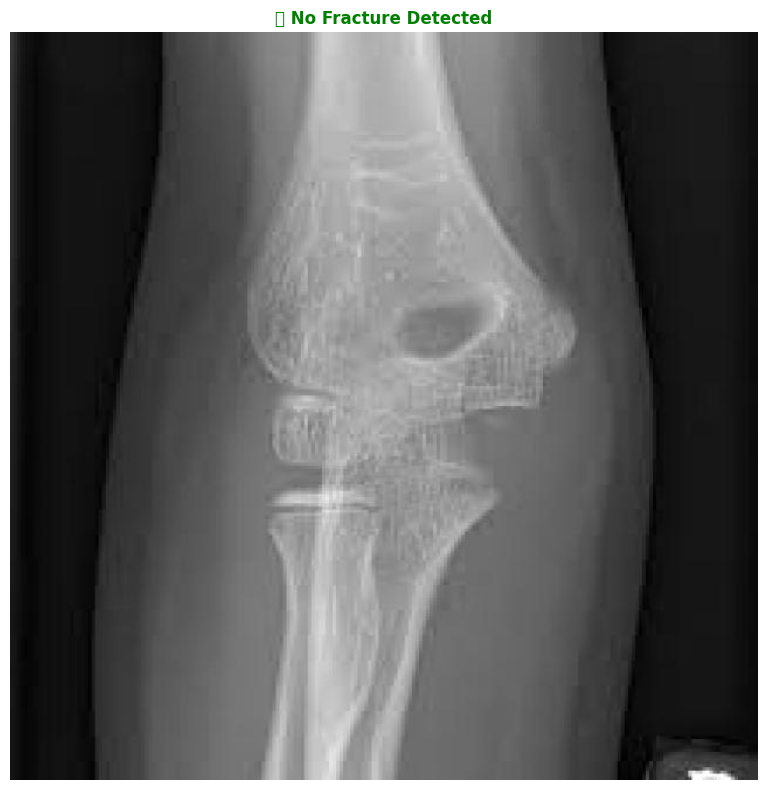


✅ Test complete! Interface is ready to launch.


In [7]:
# ============================================================================
# BLOCK 4: QUICK TEST - Verify model works with a sample image
# ============================================================================

print("="*70)
print("QUICK TEST: Verifying model with a sample image")
print("="*70)

# ========== FIND A TEST IMAGE ==========
test_images_path = r"C:\Users\andre\Documents\Graduation Project\Shoulders\Filtered_Shoulder_Arm_Dataset_FINAL\test\images"

test_image_path = None
if os.path.exists(test_images_path):
    for file in os.listdir(test_images_path):
        if file.endswith(('.jpg', '.jpeg', '.png')):
            test_image_path = os.path.join(test_images_path, file)
            break

if test_image_path is None:
    print("❌ No test image found in default path!")
    print("   Please manually set test_image_path")
    test_image_path = input("Enter path to a test image: ")

print(f"📁 Using test image: {test_image_path}")

# ========== LOAD AND TEST ==========
img = cv2.imread(test_image_path)
if img is None:
    print(f"❌ Cannot read image: {test_image_path}")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    
    # Run prediction
    threshold = 0.3
    print(f"\n🔍 Running prediction with threshold={threshold}")
    print("-"*50)
    
    annotated_img, result_html, has_fracture, num_fractures = predict_fracture(img_pil, threshold)
    
    # Display results
    print(f"\n📊 RESULTS:")
    print(f"   Has fracture: {has_fracture}")
    print(f"   Number of fractures: {num_fractures}")
    
    # Display the annotated image
    if annotated_img is not None:
        plt.figure(figsize=(10, 8))
        plt.imshow(annotated_img)
        plt.axis('off')
        if has_fracture:
            plt.title(f"⚠️ {num_fractures} Fracture(s) Detected", color='red', fontweight='bold')
        else:
            plt.title("✅ No Fracture Detected", color='green', fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    print("\n✅ Test complete! Interface is ready to launch.")

print("="*70)

In [9]:
# ============================================================================
# BLOCK 5: GRADIO WEB INTERFACE (Professional UI)
# ============================================================================

print("="*70)
print("LAUNCHING GRADIO WEB INTERFACE")
print("="*70)

import gradio as gr

def gradio_predict(image, threshold):
    """Wrapper for Gradio interface"""
    if image is None:
        return None, "Please upload an image."
    
    # Convert Gradio image to PIL if needed
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image)
    
    # Run prediction
    annotated_img, result_text, has_fracture, num_fractures = predict_fracture(image, threshold)
    
    return annotated_img, result_text

# Create Gradio interface
with gr.Blocks(theme=gr.themes.Soft(), title="AETHEA Shoulder & Arm Fracture Detection") as demo:
    gr.Markdown("""
    # 🏥 AETHEA Shoulder & Arm Fracture Detection System
    
    Upload an X-ray image of a **shoulder or arm** to detect potential fractures using AI.
    
    **Model Performance:** Best AP50: 61.56% | Trained on 15,449 images
    """)
    
    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(type="pil", label="Upload Shoulder/Arm X-ray", height=400)
            
            threshold = gr.Slider(
                minimum=0.1,
                maximum=0.9,
                value=0.3,
                step=0.05,
                label="Detection Threshold",
                info="Lower = more sensitive (more detections), Higher = more specific (fewer false positives)"
            )
            
            submit_btn = gr.Button("🔍 Detect Fracture", variant="primary", size="lg")
        
        with gr.Column(scale=1):
            image_output = gr.Image(label="Analysis Result", height=400)
    
    with gr.Row():
        result_output = gr.HTML(label="Diagnosis Report")
    
    submit_btn.click(
        fn=gradio_predict,
        inputs=[image_input, threshold],
        outputs=[image_output, result_output]
    )
    
    gr.Markdown("""
    ---
    ### 📋 Instructions
    1. Upload a shoulder or arm X-ray image (JPG, PNG)
    2. Adjust threshold if needed (0.3 is recommended)
    3. Click "Detect Fracture" to analyze
    
    ### 🎯 Threshold Guide
    | Threshold | Sensitivity | Use Case |
    |-----------|-------------|----------|
    | 0.2 | High | Catch subtle fractures (more false positives) |
    | 0.3 | Balanced | Default recommendation |
    | 0.5 | Low | Only confident detections |
    
    ### ⚕️ Medical Disclaimer
    This is an AI screening tool. All results must be verified by qualified healthcare professionals.
    """)

# Launch
demo.launch(share=True, debug=False)

print("\n✅ Gradio interface launched!")
print("📤 Share the public link above with others")
print("="*70)

LAUNCHING GRADIO WEB INTERFACE
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://e0127a44c37733821f.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



✅ Gradio interface launched!
📤 Share the public link above with others


LAUNCHING FIXED TEST INTERFACE


HTML(value='<h2>🦴 Hips & Pelvis Fracture Detection</h2>')

HTML(value="<p style='color: #e53e3e;'><strong>Note:</strong> Only fracture classes will show bounding boxes. …

FileUpload(value={}, accept='image/*', description='📤 Upload X-ray')

FloatSlider(value=0.3, description='Threshold:', max=0.9, min=0.1, step=0.05, style=SliderStyle(description_wi…

Button(button_style='primary', description='🔍 Analyze Image', layout=Layout(width='200px'), style=ButtonStyle(…


✅ Fixed interface ready!
   - Results are consistent for same threshold
   - Only ACTUAL fractures show bounding boxes
   - 'No Fracture' predictions show NO boxes

📤 Upload a hip/pelvis X-ray and click 'Analyze Image'


LAUNCHING FIXED GRADIO WEB INTERFACE

🚀 Launching fixed Gradio interface...
* Running on local URL:  http://127.0.0.1:7863

To create a public link, set `share=True` in `launch()`.



✅ Fixed Gradio interface launched!
   - Results are now consistent for same threshold
   - Only actual fractures show bounding boxes
